<a href="https://colab.research.google.com/github/jjlizcano/brain-stroke-segmentation/blob/main/brain_stroke_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Instalación y actualización de librerías
!pip install -q --upgrade kagglehub nibabel matplotlib
import kagglehub
import os
import nibabel as nib
import matplotlib.pyplot as plt
import nibabel as nib
import matplotlib.pyplot as plt
import random

# 2. Clonar o actualizar el repositorio

REPO_URL = "https://github.com/jjlizcano/brain-stroke-segmentation.git"
REPO_DIR = "brain-stroke-segmentation"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
else:
    %cd {REPO_DIR}
    !git pull
    %cd ..

print("Repositorio listo en:", REPO_DIR)

Cloning into 'brain-stroke-segmentation'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 6 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), done.
Resolving deltas: 100% (1/1), done.
Repositorio listo en: brain-stroke-segmentation


# Importar dataset

In [ ]:
path = kagglehub.dataset_download("orvile/isles-2022-brain-stoke-dataset")
print("Los archivos se descargaron en:", path)

Using Colab cache for faster access to the 'isles-2022-brain-stoke-dataset' dataset.
Los archivos se descargaron en: /kaggle/input/isles-2022-brain-stoke-dataset


# Filtrado de archivos
Out of an initial set of 1000 NIfTI files, 500 DWI/ADC files were successfully identified and filtered, excluding FLAIR images.

In [46]:
dwi_adc_files = []

for file_path in files:
    filename_lower = file_path.lower() # Convert to lowercase for case-insensitive check

    # Check if 'dwi' or 'adc' is in the path and 'flair' is not
    if ('dwi' in filename_lower or 'adc' in filename_lower) and 'flair' not in filename_lower:
        dwi_adc_files.append(file_path)

print(f"Se encontraron {len(dwi_adc_files)} archivos DWI/ADC después de filtrar.")
print("Primeros 5 archivos DWI/ADC:")
for f in dwi_adc_files[:5]:
    print(f)

Se encontraron 500 archivos DWI/ADC después de filtrar.
Primeros 5 archivos DWI/ADC:
/kaggle/input/isles-2022-brain-stoke-dataset/ISLES-2022/ISLES-2022/sub-strokecase0202/ses-0001/dwi/sub-strokecase0202_ses-0001_dwi.nii/dwi_skull-stripped.nii
/kaggle/input/isles-2022-brain-stoke-dataset/ISLES-2022/ISLES-2022/sub-strokecase0202/ses-0001/dwi/sub-strokecase0202_ses-0001_adc.nii/adc_skull-stripped.nii
/kaggle/input/isles-2022-brain-stoke-dataset/ISLES-2022/ISLES-2022/sub-strokecase0242/ses-0001/dwi/sub-strokecase0242_ses-0001_adc.nii/sub-basilarstroke0076_ses-20200607_ornt-iso_skull-stripped_sequ-204_adc.nii
/kaggle/input/isles-2022-brain-stoke-dataset/ISLES-2022/ISLES-2022/sub-strokecase0242/ses-0001/dwi/sub-strokecase0242_ses-0001_dwi.nii/sub-basilarstroke0076_ses-20200607_ornt-iso_skull-stripped_sequ-203_dwi.nii
/kaggle/input/isles-2022-brain-stoke-dataset/ISLES-2022/ISLES-2022/sub-strokecase0219/ses-0001/dwi/sub-strokecase0219_ses-0001_adc.nii/adc_skull-stripped.nii


# Visualización de imágenes
Una imagen DWI de ejemplo y una imagen ADC de ejemplo y sus cortes centrales para confirmar la capacidad de acceder y visualizar los datos de imagen para ambas modalidades.

Visualizando imagen DWI: /kaggle/input/isles-2022-brain-stoke-dataset/ISLES-2022/ISLES-2022/sub-strokecase0202/ses-0001/dwi/sub-strokecase0202_ses-0001_dwi.nii/dwi_skull-stripped.nii


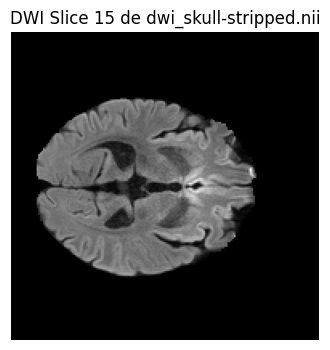

Visualizando imagen ADC: /kaggle/input/isles-2022-brain-stoke-dataset/ISLES-2022/ISLES-2022/sub-strokecase0202/ses-0001/dwi/sub-strokecase0202_ses-0001_adc.nii/adc_skull-stripped.nii


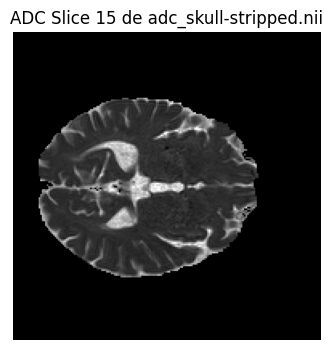

In [47]:
dwi_image_path = None
adc_image_path = None

for file_path in dwi_adc_files:
    filename_lower = file_path.lower()
    if 'dwi' in filename_lower and dwi_image_path is None:
        dwi_image_path = file_path
    elif 'adc' in filename_lower and adc_image_path is None:
        adc_image_path = file_path
    if dwi_image_path and adc_image_path:
        break

if dwi_image_path:
    print(f"Visualizando imagen DWI: {dwi_image_path}")
    dwi_data = nib.load(dwi_image_path).get_fdata()
    dwi_slice_idx = dwi_data.shape[2] // 2
    plt.figure(figsize=(8, 4))
    plt.imshow(dwi_data[:, :, dwi_slice_idx], cmap='gray')
    plt.title(f"DWI Slice {dwi_slice_idx} de {os.path.basename(dwi_image_path)}")
    plt.axis('off')
    plt.show()
else:
    print("No se encontr\u00f3 ninguna imagen DWI para visualizar.")

if adc_image_path:
    print(f"Visualizando imagen ADC: {adc_image_path}")
    adc_data = nib.load(adc_image_path).get_fdata()
    adc_slice_idx = adc_data.shape[2] // 2
    plt.figure(figsize=(8, 4))
    plt.imshow(adc_data[:, :, adc_slice_idx], cmap='gray')
    plt.title(f"ADC Slice {adc_slice_idx} de {os.path.basename(adc_image_path)}")
    plt.axis('off')
    plt.show()
else:
    print("No se encontr\u00f3 ninguna imagen ADC para visualizar.")